<a href="https://colab.research.google.com/github/harshgupta170704/Research-Paper-Search-Engine/blob/main/Analysis%20of%20growth%20of%20multicellular%20tumour%20spheroids%20by%20mathematical%20models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

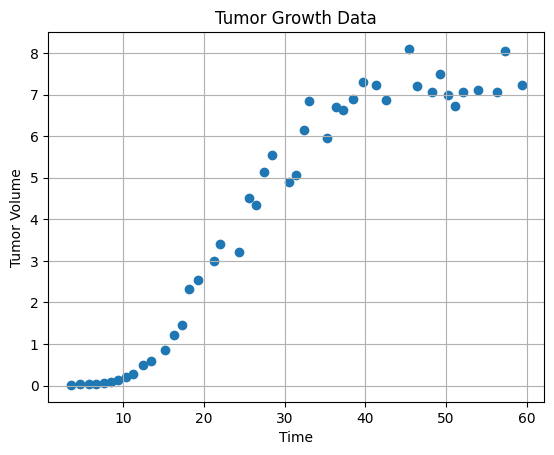


Verhulst Model Parameters:
k = 0.256909591371931
C = 7.090248539869679

Montroll Model Parameters:
k = 0.23378569676114494
C = 7.2108851634000946
theta = 1.4006078178509715


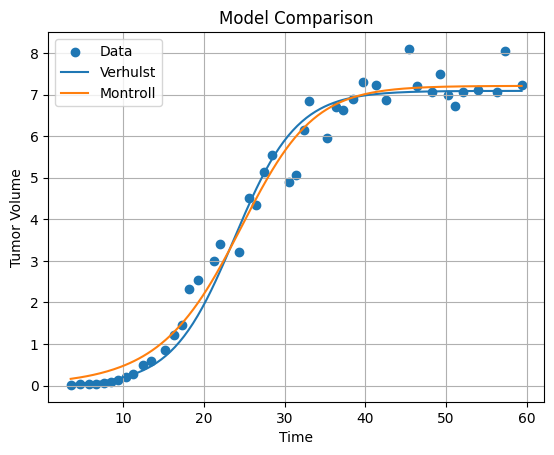


Model Errors:
Verhulst Error: 0.20301723017830414
Montroll Error: 0.156470512020488

Conclusion:
Montroll model fits the data better.
Reason: Extra parameter (theta) improves flexibility.
Both models show logistic growth behavior with saturation.


In [1]:
# ============================================
# Tumor Growth Modeling (Complete Script)
# ============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from sklearn.metrics import mean_squared_error

# ============================================
# 1. DATASET (from paper Table 1)
# ============================================

data = [
    [3.46,0.0158],[4.58,0.0264],[5.67,0.0326],[6.64,0.0445],
    [7.63,0.0646],[8.41,0.0933],[9.32,0.1454],[10.27,0.2183],
    [11.19,0.2842],[12.39,0.4977],[13.42,0.6033],[15.19,0.8441],
    [16.24,1.2163],[17.23,1.4470],[18.18,2.3298],[19.29,2.5342],
    [21.23,3.0064],[21.99,3.4044],[24.33,3.2046],[25.58,4.5241],
    [26.43,4.3459],[27.44,5.1374],[28.43,5.5376],[30.49,4.8946],
    [31.34,5.0660],[32.34,6.1494],[33.00,6.8548],[35.20,5.9668],
    [36.34,6.6945],[37.29,6.6395],[38.50,6.8971],[39.67,7.2966],
    [41.37,7.2268],[42.58,6.8815],[45.39,8.0993],[46.38,7.2112],
    [48.29,7.0694],[49.24,7.4971],[50.19,6.9974],[51.14,6.7219],
    [52.10,7.0523],[54.00,7.1095],[56.33,7.0694],[57.33,8.0562],
    [59.38,7.2268]
]

df = pd.DataFrame(data, columns=["t", "V"])

# ============================================
# 2. RAW DATA VISUALIZATION
# ============================================

plt.figure()
plt.scatter(df["t"], df["V"])
plt.xlabel("Time")
plt.ylabel("Tumor Volume")
plt.title("Tumor Growth Data")
plt.grid()
plt.savefig("raw_data.png")
plt.show()

# ============================================
# 3. VERHULST MODEL
# ============================================

def verhulst(t, k, C):
    P0 = df["V"].iloc[0]
    return C / (1 + ((C - P0)/P0) * np.exp(-k*t))

params_v, _ = curve_fit(verhulst, df["t"], df["V"], p0=[0.5, 8])
k_v, C_v = params_v

print("\nVerhulst Model Parameters:")
print("k =", k_v)
print("C =", C_v)

# ============================================
# 4. MONTROLL MODEL
# ============================================

def montroll(t, k, C, theta):
    P0 = df["V"].iloc[0]
    return C / (1 + ((C - P0)/P0) * np.exp(-k*t))**(1/theta)

params_m, _ = curve_fit(montroll, df["t"], df["V"], p0=[0.5, 8, 0.2])
k_m, C_m, theta_m = params_m

print("\nMontroll Model Parameters:")
print("k =", k_m)
print("C =", C_m)
print("theta =", theta_m)

# ============================================
# 5. PLOT BOTH MODELS
# ============================================

t_vals = np.linspace(min(df["t"]), max(df["t"]), 200)

plt.figure()
plt.scatter(df["t"], df["V"], label="Data")
plt.plot(t_vals, verhulst(t_vals, k_v, C_v), label="Verhulst")
plt.plot(t_vals, montroll(t_vals, k_m, C_m, theta_m), label="Montroll")
plt.xlabel("Time")
plt.ylabel("Tumor Volume")
plt.title("Model Comparison")
plt.legend()
plt.grid()
plt.savefig("model_comparison.png")
plt.show()

# ============================================
# 6. ERROR CALCULATION
# ============================================

ver_pred = verhulst(df["t"], k_v, C_v)
mon_pred = montroll(df["t"], k_m, C_m, theta_m)

ver_error = mean_squared_error(df["V"], ver_pred)
mon_error = mean_squared_error(df["V"], mon_pred)

print("\nModel Errors:")
print("Verhulst Error:", ver_error)
print("Montroll Error:", mon_error)

# ============================================
# 7. FINAL CONCLUSION
# ============================================

print("\nConclusion:")
if mon_error < ver_error:
    print("Montroll model fits the data better.")
    print("Reason: Extra parameter (theta) improves flexibility.")
else:
    print("Verhulst model fits better (rare case).")

print("Both models show logistic growth behavior with saturation.")